In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Define data directory
data_dir = Path('TUTORIAL__1')

# Load prices data
prices_day_m1 = pd.read_csv(data_dir / 'prices_round_0_day_-1.csv', sep=';')
prices_day_m2 = pd.read_csv(data_dir / 'prices_round_0_day_-2.csv', sep=';')

# Load trades data
trades_day_m1 = pd.read_csv(data_dir / 'trades_round_0_day_-1.csv', sep=';')
trades_day_m2 = pd.read_csv(data_dir / 'trades_round_0_day_-2.csv', sep=';')

# Combine prices data
prices = pd.concat([prices_day_m2, prices_day_m1], ignore_index=True)
trades = pd.concat([trades_day_m2, trades_day_m1], ignore_index=True)

print("Prices Data shape:", prices.shape)
print("Trades Data shape:", trades.shape)
print("\nPrices Data Info:")
print(prices.head())
print("\nTrades Data Info:")
print(trades.head())

Prices Data shape: (40000, 17)
Trades Data shape: (1219, 7)

Prices Data Info:
   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  \
0   -2          0  EMERALDS         9992            11         9990   
1   -2          0  TOMATOES         4993             7         4992   
2   -2        100  TOMATOES         4998             5         4993   
3   -2        100  EMERALDS         9992            15         9990   
4   -2        200  TOMATOES         4994             6         4993   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0            25          NaN           NaN        10008            11   
1            17          NaN           NaN         5007             7   
2             7       4992.0          16.0         5007             7   
3            20          NaN           NaN        10008            15   
4            20          NaN           NaN         5008             6   

   ask_price_2  ask_volume_2  ask_price_3  ask_volume_3

## Product-wise Data Overview and Statistics

In [2]:
# Product-wise summary statistics
print("=== PRICE DATA STATISTICS (SEPARATE BY PRODUCT) ===")
for product in sorted(prices['product'].unique()):
    product_prices = prices[prices['product'] == product].copy()
    
    print("\n" + "-" * 60)
    print(f"PRODUCT: {product}")
    print("-" * 60)
    print("Mid Price Summary:")
    print(product_prices['mid_price'].describe())
    
    print("\nBid/Ask Summary:")
    print(product_prices[['bid_price_1', 'ask_price_1']].describe())
    
    product_prices['spread'] = product_prices['ask_price_1'] - product_prices['bid_price_1']
    print("\nSpread Summary:")
    print(product_prices['spread'].describe())
    
    print("\nP&L Summary:")
    print(product_prices['profit_and_loss'].describe())

print("\n\n=== TRADING ACTIVITY (SEPARATE BY SYMBOL) ===")
for symbol in sorted(trades['symbol'].unique()):
    symbol_trades = trades[trades['symbol'] == symbol].copy()
    
    print("\n" + "-" * 60)
    print(f"SYMBOL: {symbol}")
    print("-" * 60)
    print(f"Total trades: {len(symbol_trades)}")
    print(f"Total quantity: {symbol_trades['quantity'].sum()}")
    print("Price Summary:")
    print(symbol_trades['price'].describe())
    print("Quantity Summary:")
    print(symbol_trades['quantity'].describe())

=== PRICE DATA STATISTICS (SEPARATE BY PRODUCT) ===

------------------------------------------------------------
PRODUCT: EMERALDS
------------------------------------------------------------
Mid Price Summary:
count    20000.00000
mean      9999.99760
std          0.72334
min       9996.00000
25%      10000.00000
50%      10000.00000
75%      10000.00000
max      10004.00000
Name: mid_price, dtype: float64

Bid/Ask Summary:
        bid_price_1   ask_price_1
count  20000.000000  20000.000000
mean    9992.128400  10007.866800
std        1.005368      1.023675
min     9992.000000  10000.000000
25%     9992.000000  10008.000000
50%     9992.000000  10008.000000
75%     9992.000000  10008.000000
max    10000.000000  10008.000000

Spread Summary:
count    20000.000000
mean        15.738400
std          1.422838
min          8.000000
25%         16.000000
50%         16.000000
75%         16.000000
max         16.000000
Name: spread, dtype: float64

P&L Summary:
count    20000.0
mean       

## Visualization 1: Mid Price Over Time (Separate Chart Per Product and Day, with Rolling Average)

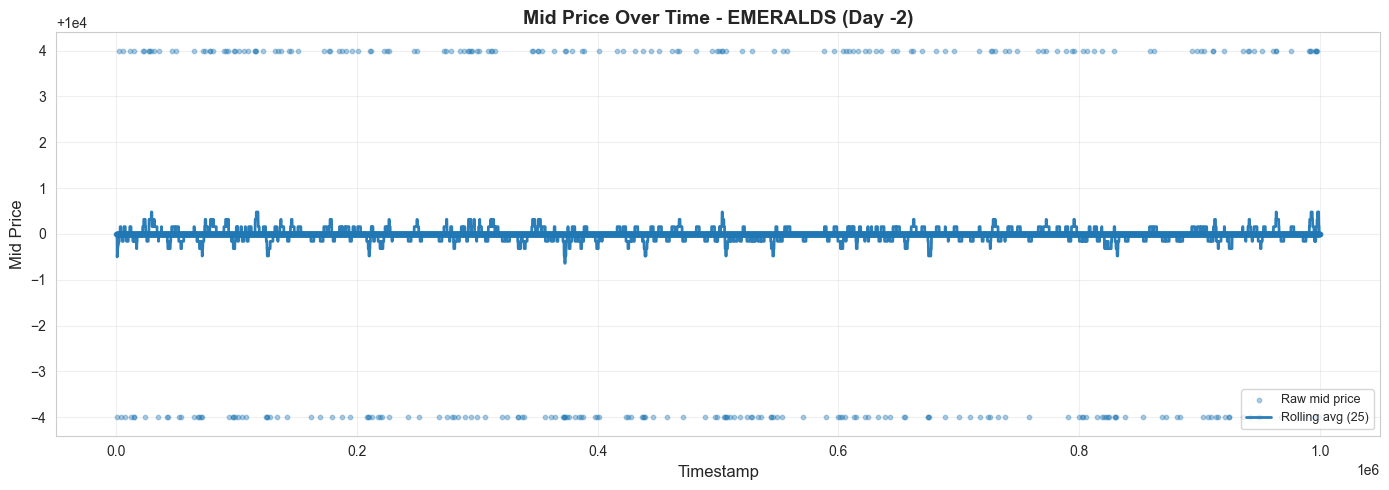

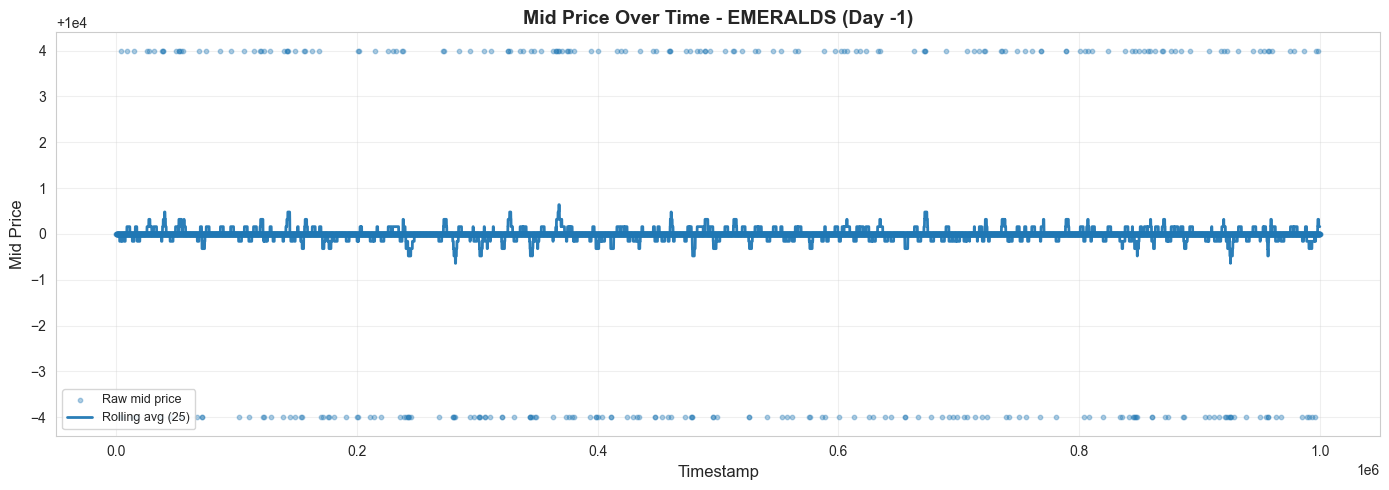

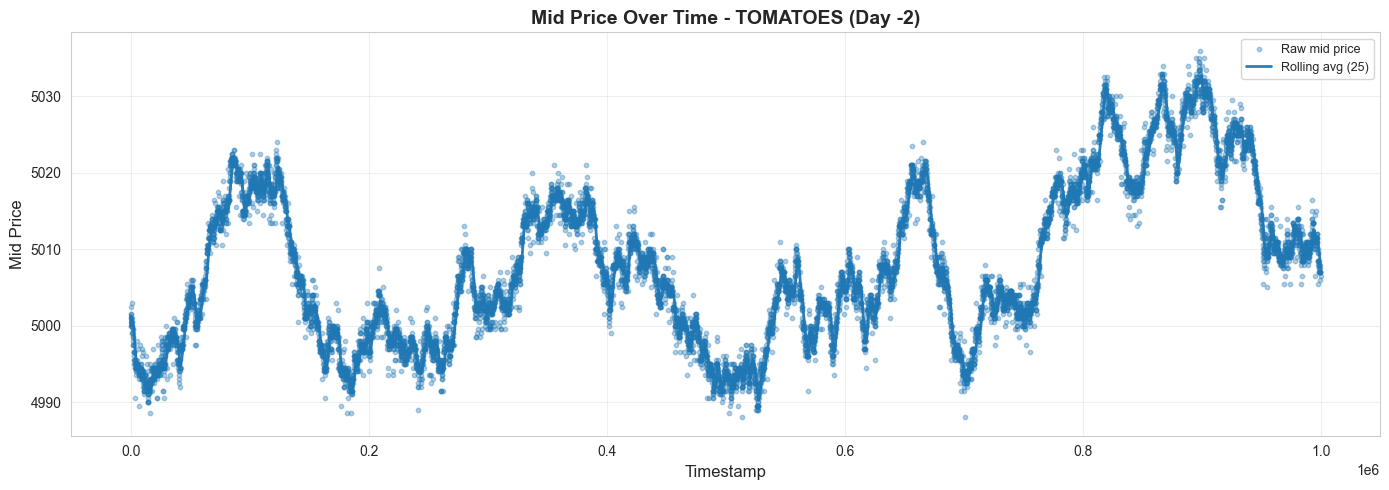

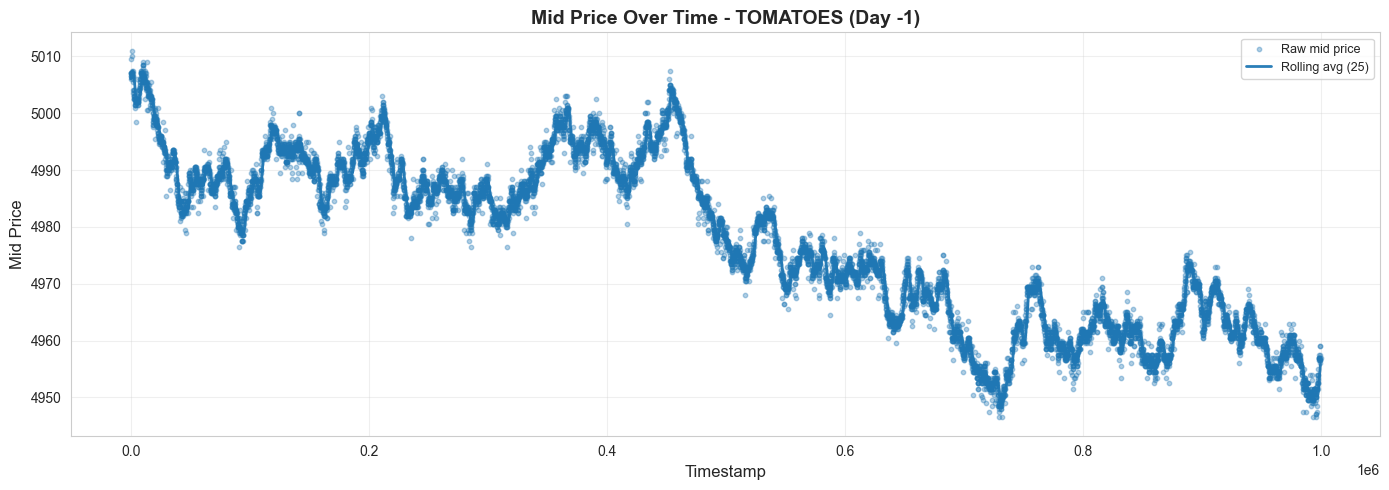

In [3]:
for product in sorted(prices['product'].unique()):
    product_data = prices[prices['product'] == product].copy()
    
    for day in sorted(product_data['day'].unique()):
        day_data = product_data[product_data['day'] == day]
        day_series = (
            day_data.groupby('timestamp', as_index=False)['mid_price']
            .mean()
            .sort_values('timestamp')
        )

        fig, ax = plt.subplots(figsize=(14, 5))

        # Use scatter for raw points to avoid visual artifacts on discrete price levels.
        ax.scatter(
            day_series['timestamp'],
            day_series['mid_price'],
            s=10,
            alpha=0.35,
            label='Raw mid price'
        )

        # Overlay a short moving average for a clearer trend view.
        trend = day_series['mid_price'].rolling(window=25, min_periods=1).mean()
        ax.plot(
            day_series['timestamp'],
            trend,
            linewidth=2.0,
            alpha=0.95,
            label='Rolling avg (25)'
        )
    
        ax.set_xlabel('Timestamp', fontsize=12)
        ax.set_ylabel('Mid Price', fontsize=12)
        ax.set_title(f'Mid Price Over Time - {product} (Day {day})', fontsize=14, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Visualization 2: Bid-Ask Spread Over Time (Separate Chart Per Product and Day, with Rolling Average)

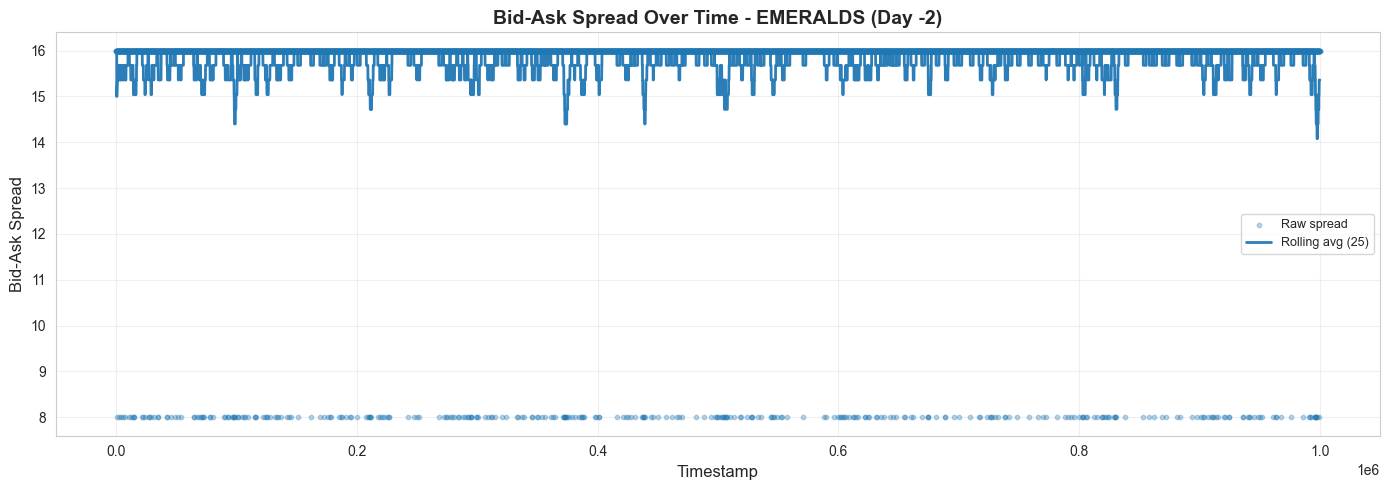

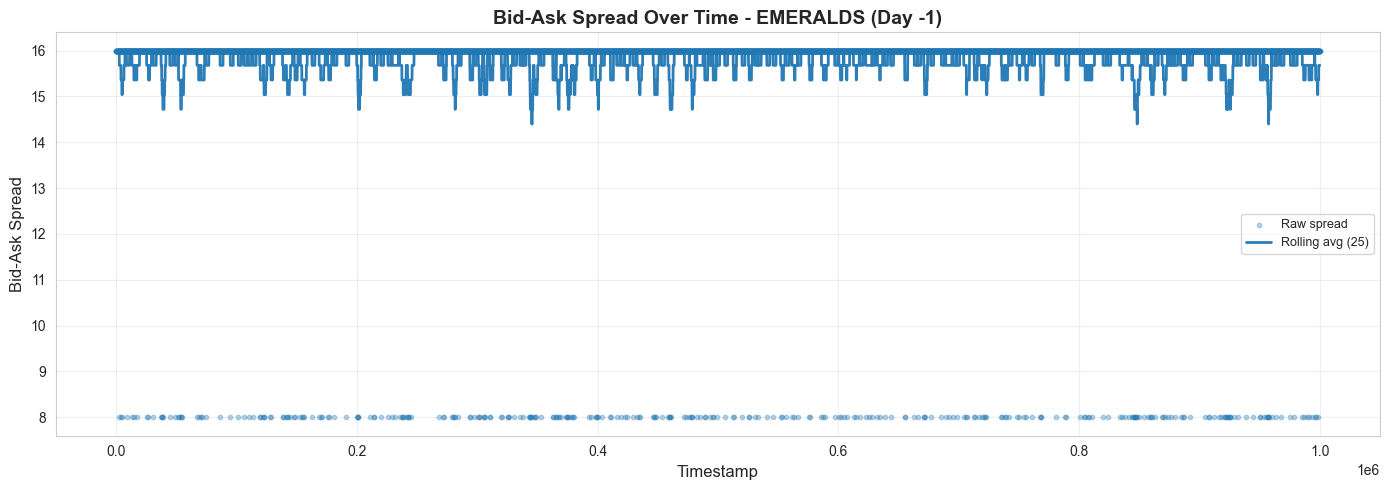

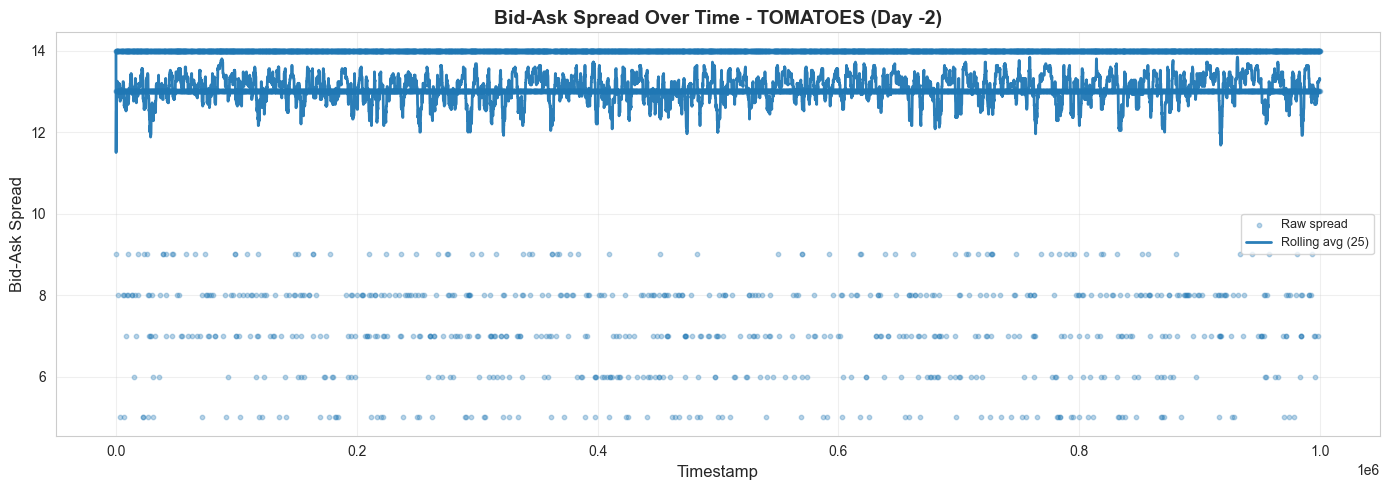

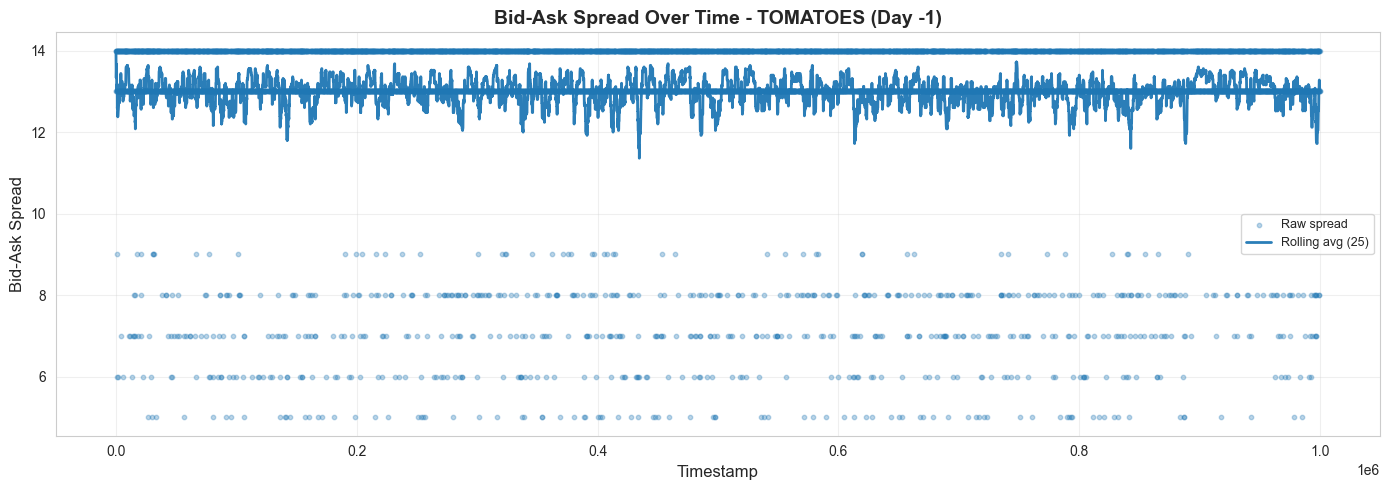

In [4]:
# Calculate bid-ask spread
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

for product in sorted(prices['product'].unique()):
    product_data = prices[prices['product'] == product].copy()
    
    for day in sorted(product_data['day'].unique()):
        day_data = product_data[product_data['day'] == day]
        day_series = (
            day_data.groupby('timestamp', as_index=False)['spread']
            .mean()
            .sort_values('timestamp')
        )

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.scatter(
            day_series['timestamp'],
            day_series['spread'],
            s=10,
            alpha=0.3,
            label='Raw spread'
        )
        trend = day_series['spread'].rolling(window=25, min_periods=1).mean()
        ax.plot(
            day_series['timestamp'],
            trend,
            linewidth=2.0,
            alpha=0.95,
            label='Rolling avg (25)'
        )

        ax.set_xlabel('Timestamp', fontsize=12)
        ax.set_ylabel('Bid-Ask Spread', fontsize=12)
        ax.set_title(f'Bid-Ask Spread Over Time - {product} (Day {day})', fontsize=14, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Visualization 3: Trading Volume and Price Distribution

C:\Users\liamb\AppData\Local\Temp\ipykernel_30676\3465768891.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(trade_prices, labels=symbols, patch_artist=True)


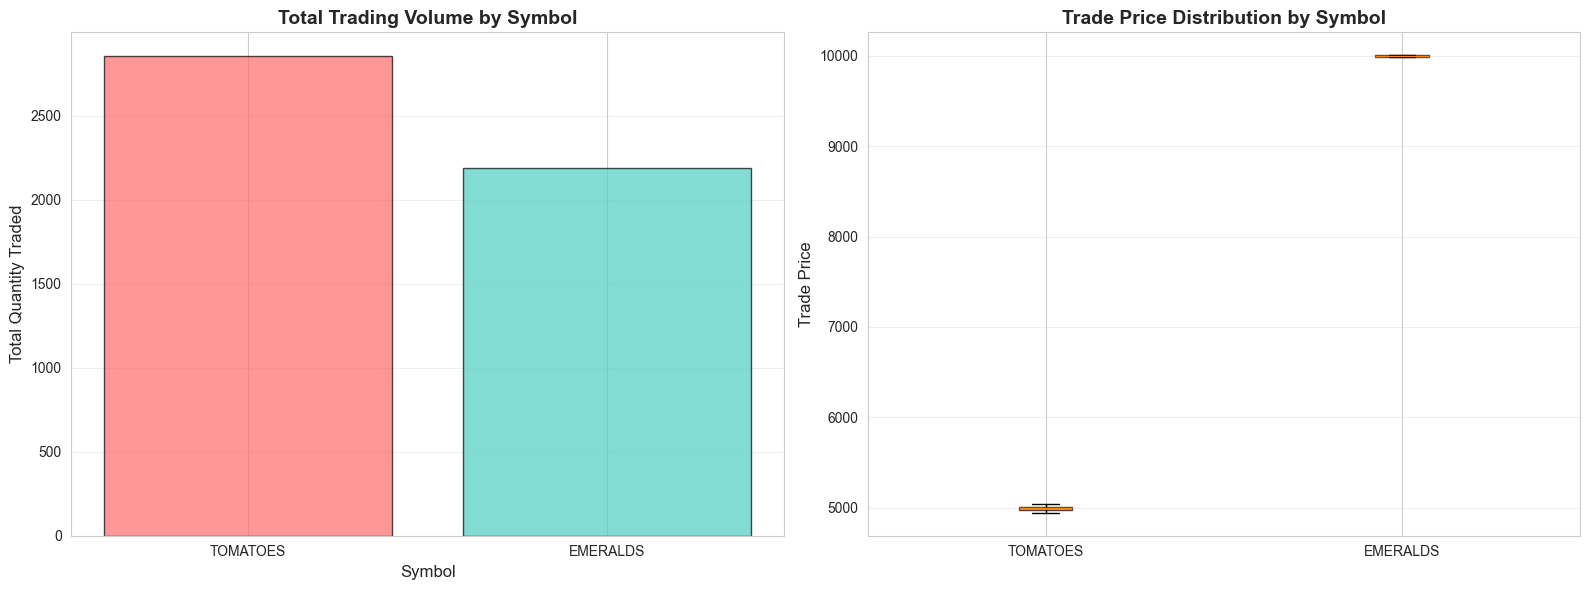

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trading volume by symbol
trades_summary = trades.groupby('symbol')['quantity'].sum().sort_values(ascending=False)
axes[0].bar(trades_summary.index, trades_summary.values, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Symbol', fontsize=12)
axes[0].set_ylabel('Total Quantity Traded', fontsize=12)
axes[0].set_title('Total Trading Volume by Symbol', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Price distribution by symbol (box plot)
symbols = trades['symbol'].unique()
trade_prices = [trades[trades['symbol'] == sym]['price'].values for sym in symbols]
bp = axes[1].boxplot(trade_prices, labels=symbols, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Trade Price', fontsize=12)
axes[1].set_title('Trade Price Distribution by Symbol', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Visualization 4: Bid and Ask Prices with Mid Price (Separate Chart Per Product and Day, with Rolling Average)

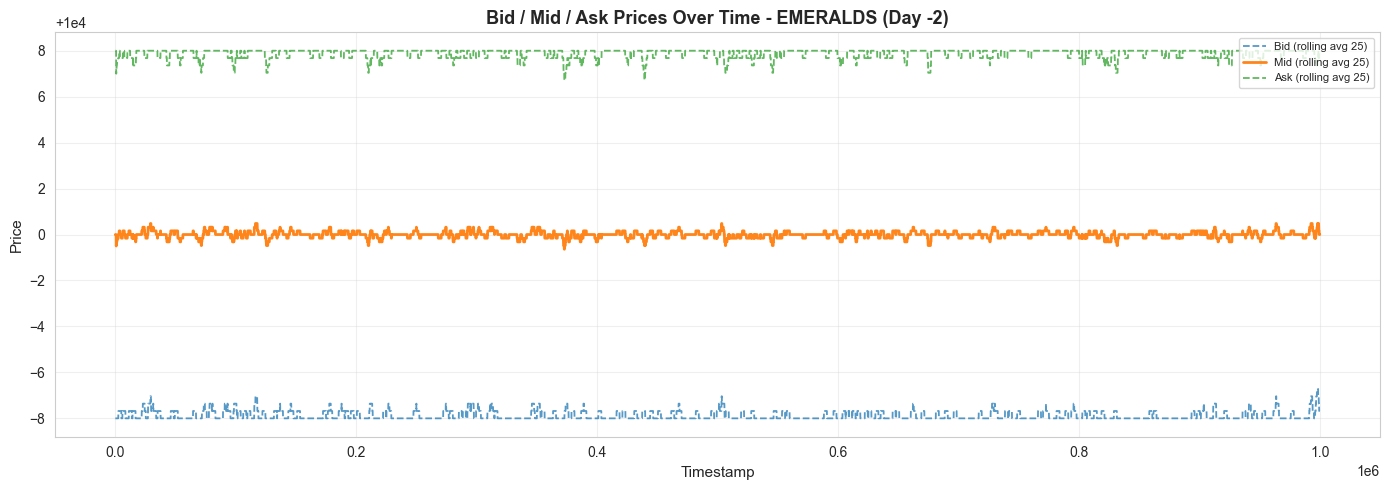

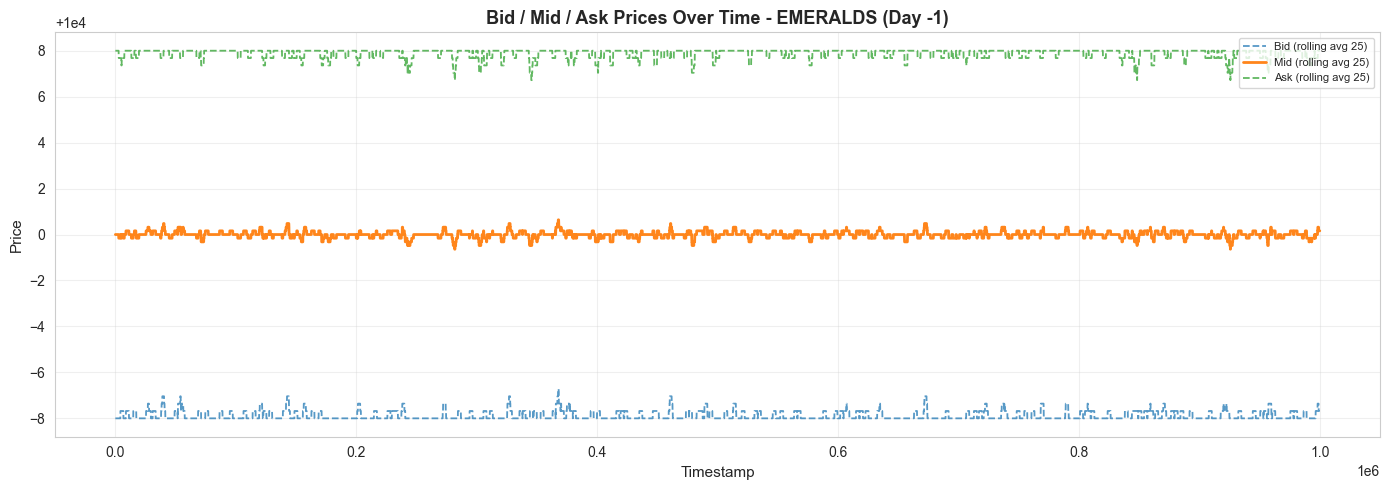

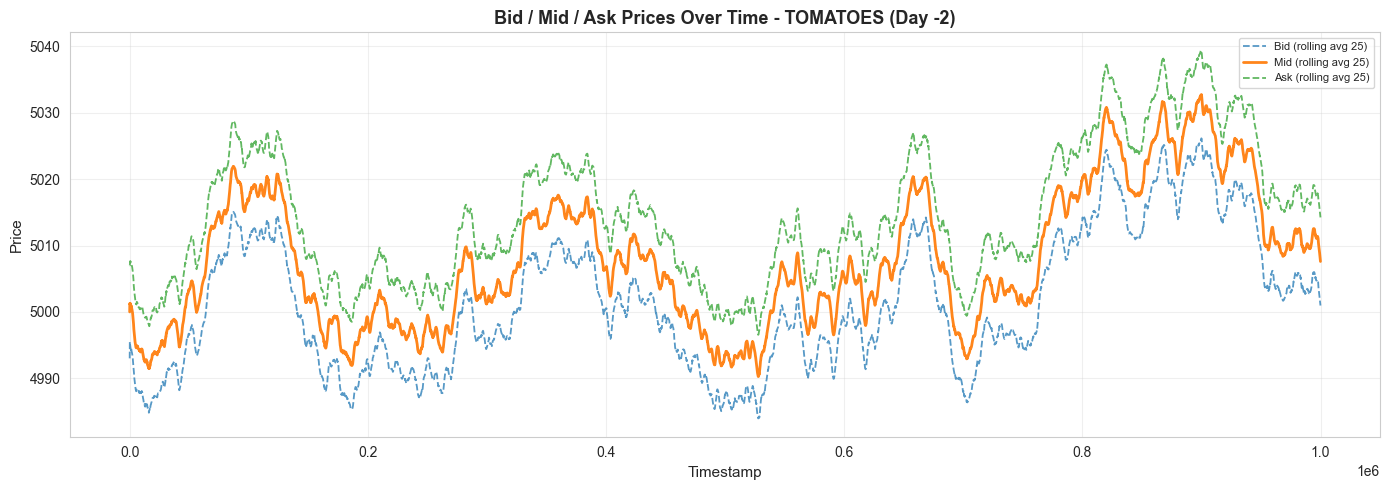

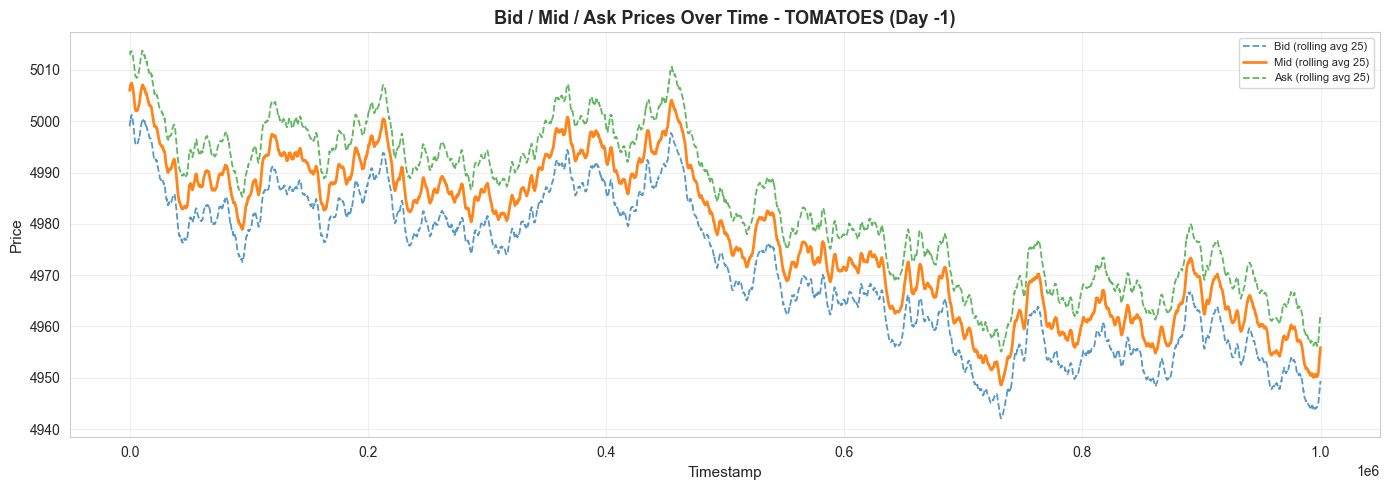

In [6]:
for product in sorted(prices['product'].unique()):
    product_data = prices[prices['product'] == product].copy()
    
    for day in sorted(product_data['day'].unique()):
        day_data = product_data[product_data['day'] == day]
        day_series = (
            day_data.groupby('timestamp', as_index=False)[['bid_price_1', 'ask_price_1', 'mid_price']]
            .mean()
            .sort_values('timestamp')
        )

        bid_trend = day_series['bid_price_1'].rolling(window=25, min_periods=1).mean()
        mid_trend = day_series['mid_price'].rolling(window=25, min_periods=1).mean()
        ask_trend = day_series['ask_price_1'].rolling(window=25, min_periods=1).mean()

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(day_series['timestamp'], bid_trend, linewidth=1.3, alpha=0.75, linestyle='--', label='Bid (rolling avg 25)')
        ax.plot(day_series['timestamp'], mid_trend, linewidth=2.0, alpha=0.95, label='Mid (rolling avg 25)')
        ax.plot(day_series['timestamp'], ask_trend, linewidth=1.3, alpha=0.75, linestyle='--', label='Ask (rolling avg 25)')
    
        ax.set_xlabel('Timestamp', fontsize=11)
        ax.set_ylabel('Price', fontsize=11)
        ax.set_title(f'Bid / Mid / Ask Prices Over Time - {product} (Day {day})', fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Visualization 5: Trading Activity Analysis

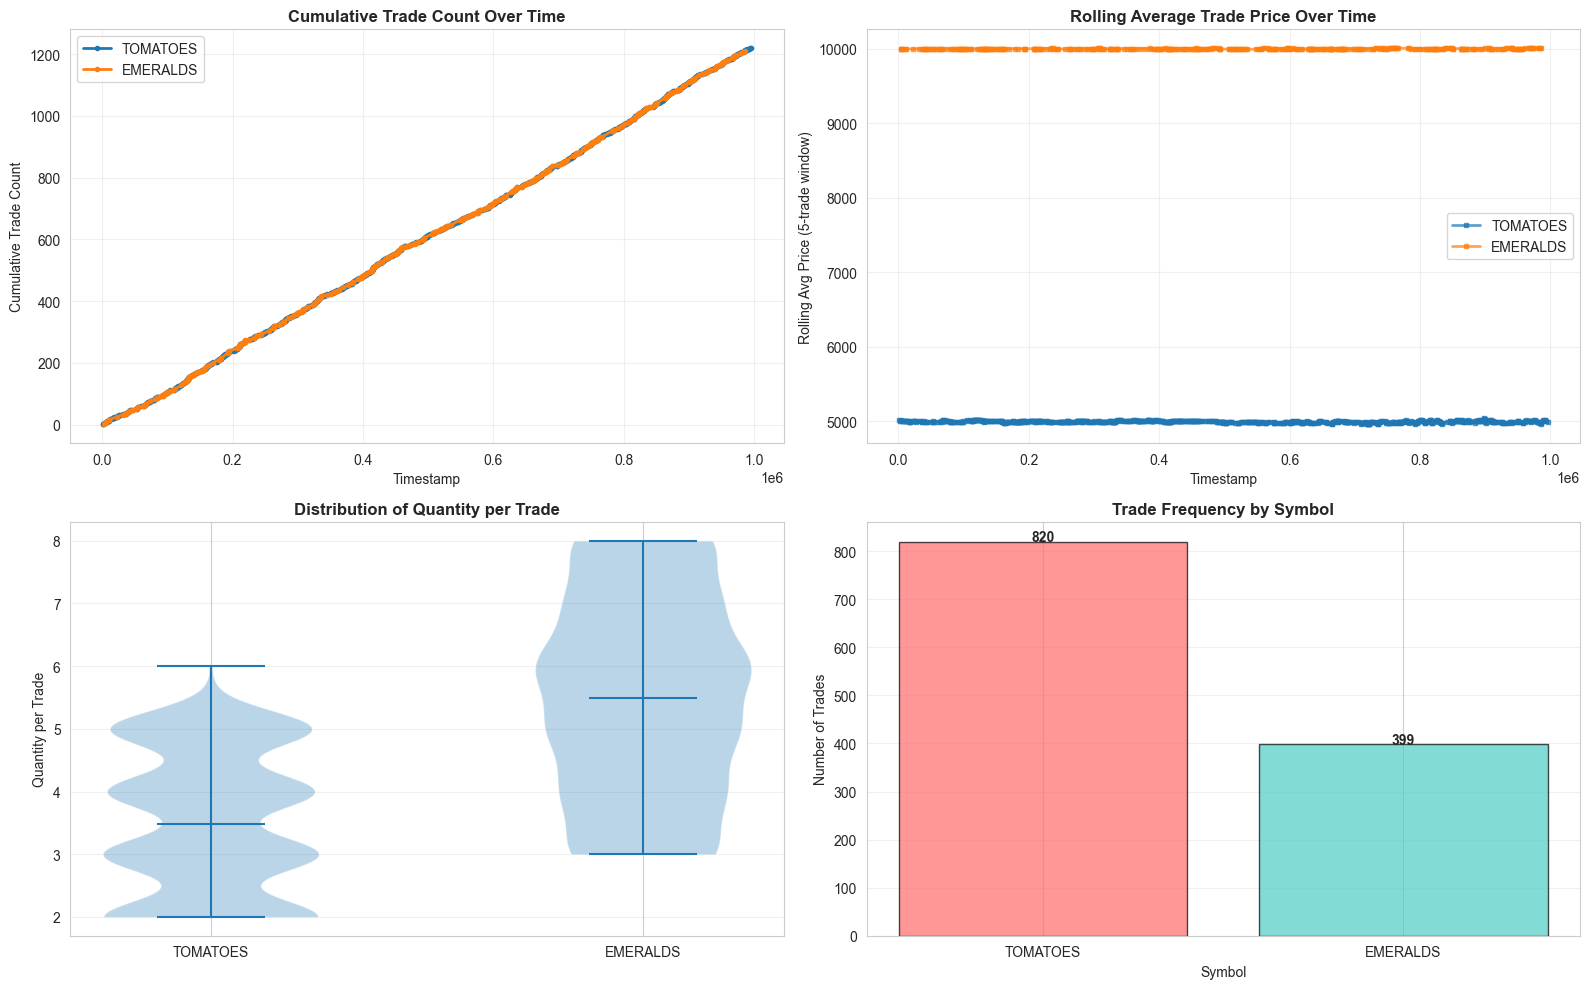

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Trade count over time
trades_sorted = trades.sort_values('timestamp')
trades_sorted['cumulative_count'] = range(1, len(trades_sorted) + 1)
for symbol in trades['symbol'].unique():
    symbol_data = trades_sorted[trades_sorted['symbol'] == symbol]
    axes[0, 0].plot(symbol_data['timestamp'], symbol_data['cumulative_count'], marker='o', 
                    label=symbol, linewidth=2, markersize=3)
axes[0, 0].set_xlabel('Timestamp', fontsize=10)
axes[0, 0].set_ylabel('Cumulative Trade Count', fontsize=10)
axes[0, 0].set_title('Cumulative Trade Count Over Time', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Average price per trade over time (rolling window)
trades_sorted['rolling_avg_price'] = trades_sorted.groupby('symbol')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
for symbol in trades['symbol'].unique():
    symbol_data = trades_sorted[trades_sorted['symbol'] == symbol]
    axes[0, 1].plot(symbol_data['timestamp'], symbol_data['rolling_avg_price'], marker='s', 
                    label=symbol, linewidth=2, markersize=3, alpha=0.7)
axes[0, 1].set_xlabel('Timestamp', fontsize=10)
axes[0, 1].set_ylabel('Rolling Avg Price (5-trade window)', fontsize=10)
axes[0, 1].set_title('Rolling Average Trade Price Over Time', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Quantity per trade
trade_symbols = trades['symbol'].unique()
trade_quantities = [trades[trades['symbol'] == sym]['quantity'].values for sym in trade_symbols]
positions = np.arange(len(trade_symbols))
axes[1, 0].violinplot(trade_quantities, positions=positions, showmeans=True)
axes[1, 0].set_xticks(positions)
axes[1, 0].set_xticklabels(trade_symbols)
axes[1, 0].set_ylabel('Quantity per Trade', fontsize=10)
axes[1, 0].set_title('Distribution of Quantity per Trade', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Trade frequency histogram
trades_by_symbol = trades['symbol'].value_counts()
axes[1, 1].bar(trades_by_symbol.index, trades_by_symbol.values, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Symbol', fontsize=10)
axes[1, 1].set_ylabel('Number of Trades', fontsize=10)
axes[1, 1].set_title('Trade Frequency by Symbol', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, (symbol, count) in enumerate(zip(trades_by_symbol.index, trades_by_symbol.values)):
    axes[1, 1].text(i, count + 0.5, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Summary Insights

In [8]:
# Generate key insights
print("=" * 70)
print("KEY INSIGHTS FROM THE ANALYSIS")
print("=" * 70)

print("\n1. PRICE MOVEMENT:")
for product in prices['product'].unique():
    product_data = prices[prices['product'] == product]
    price_min = product_data['mid_price'].min()
    price_max = product_data['mid_price'].max()
    price_range = price_max - price_min
    print(f"   {product}: Min=${price_min:.2f}, Max=${price_max:.2f}, Range=${price_range:.2f}")

print("\n2. BID-ASK SPREAD:")
for product in prices['product'].unique():
    product_data = prices[prices['product'] == product]
    avg_spread = product_data['spread'].mean()
    max_spread = product_data['spread'].max()
    print(f"   {product}: Avg Spread=${avg_spread:.2f}, Max Spread=${max_spread:.2f}")

print("\n3. TRADING VOLUME:")
for symbol in trades['symbol'].unique():
    symbol_trades = trades[trades['symbol'] == symbol]
    total_quantity = symbol_trades['quantity'].sum()
    total_trades = len(symbol_trades)
    avg_quantity = symbol_trades['quantity'].mean()
    print(f"   {symbol}: {total_trades} trades, {total_quantity} units, Avg per trade: {avg_quantity:.2f}")

print("\n4. TRADING PRICE RANGES:")
for symbol in trades['symbol'].unique():
    symbol_trades = trades[trades['symbol'] == symbol]
    print(f"   {symbol}: Min=${symbol_trades['price'].min():.2f}, Max=${symbol_trades['price'].max():.2f}, Avg=${symbol_trades['price'].mean():.2f}")

print("\n" + "=" * 70)

KEY INSIGHTS FROM THE ANALYSIS

1. PRICE MOVEMENT:
   EMERALDS: Min=$9996.00, Max=$10004.00, Range=$8.00
   TOMATOES: Min=$4946.50, Max=$5036.00, Range=$89.50

2. BID-ASK SPREAD:
   EMERALDS: Avg Spread=$15.74, Max Spread=$16.00
   TOMATOES: Avg Spread=$13.02, Max Spread=$14.00

3. TRADING VOLUME:
   TOMATOES: 820 trades, 2853 units, Avg per trade: 3.48
   EMERALDS: 399 trades, 2189 units, Avg per trade: 5.49

4. TRADING PRICE RANGES:
   TOMATOES: Min=$4943.00, Max=$5040.00, Avg=$4992.57
   EMERALDS: Min=$9992.00, Max=$10008.00, Avg=$9999.80



## Visualization: Bid/Ask Price with Spread (Per Product)

In [9]:
%pip install mplfinance -q

Note: you may need to restart the kernel to use updated packages.


d:\source\prosperity\.venv\Scripts\python.exe: No module named pip


d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:592: RuntimeWarning: All-NaN slice encountered
  miny = np.nanmin(_lows)
d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:593: RuntimeWarning: All-NaN slice encountered
  maxy = np.nanmax(_highs)
d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:751: RuntimeWarning: All-NaN slice encountered
  lo = math.log(max(math.fabs(np.nanmin(lows)),1e-7),10) - 0.5
d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:752: RuntimeWarning: All-NaN slice encountered
  hi = math.log(max(math.fabs(np.nanmax(highs)),1e-7),10) + 0.5


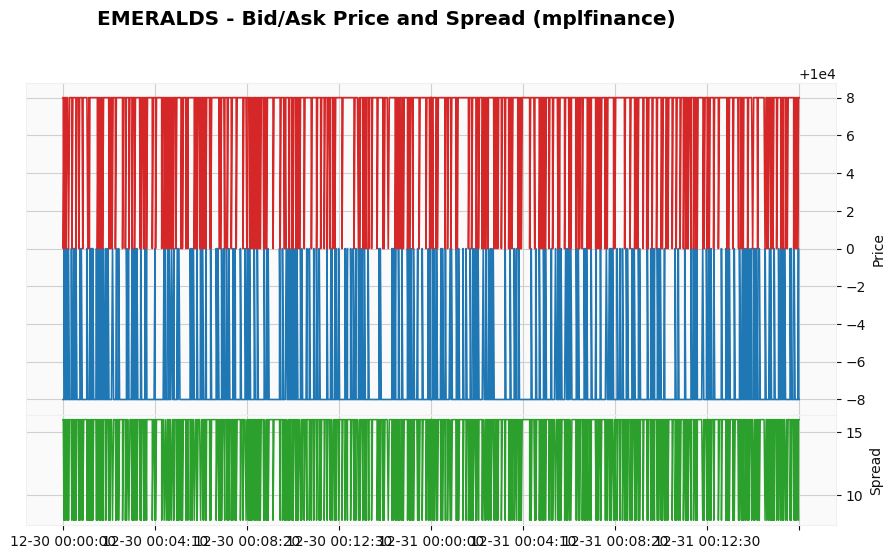

d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:592: RuntimeWarning: All-NaN slice encountered
  miny = np.nanmin(_lows)
d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:593: RuntimeWarning: All-NaN slice encountered
  maxy = np.nanmax(_highs)
d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:751: RuntimeWarning: All-NaN slice encountered
  lo = math.log(max(math.fabs(np.nanmin(lows)),1e-7),10) - 0.5
d:\source\prosperity\.venv\Lib\site-packages\mplfinance\plotting.py:752: RuntimeWarning: All-NaN slice encountered
  hi = math.log(max(math.fabs(np.nanmax(highs)),1e-7),10) + 0.5


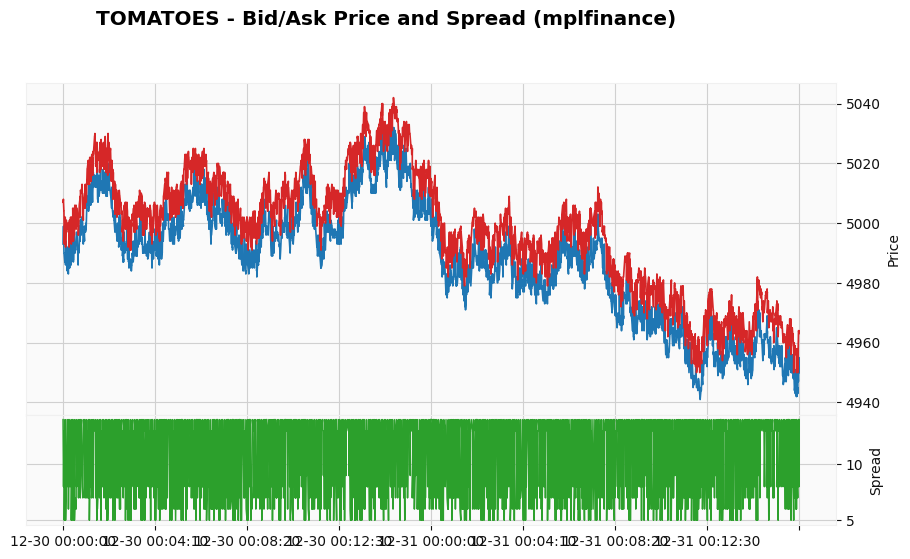

In [10]:
import pandas as pd
from pathlib import Path
import mplfinance as mpf

# Reuse existing prices dataframe if available; otherwise load from files.
if 'prices' not in globals():
    data_dir = Path('TUTORIAL__1')
    prices_day_m1 = pd.read_csv(data_dir / 'prices_round_0_day_-1.csv', sep=';')
    prices_day_m2 = pd.read_csv(data_dir / 'prices_round_0_day_-2.csv', sep=';')
    prices = pd.concat([prices_day_m2, prices_day_m1], ignore_index=True)

plot_df = prices.copy()
plot_df['spread'] = plot_df['ask_price_1'] - plot_df['bid_price_1']
plot_df['mid_price_for_ohlc'] = (plot_df['bid_price_1'] + plot_df['ask_price_1']) / 2.0

for product in sorted(plot_df['product'].unique()):
    product_data = (
        plot_df[plot_df['product'] == product]
        .groupby(['day', 'timestamp'], as_index=False)[['bid_price_1', 'ask_price_1', 'spread', 'mid_price_for_ohlc']]
        .mean()
        .sort_values(['day', 'timestamp'])
        .reset_index(drop=True)
    )

    # mplfinance expects a DatetimeIndex; build one from day + timestamp.
    base_date = pd.Timestamp('2026-01-01')
    product_data['plot_time'] = (
        base_date
        + pd.to_timedelta(product_data['day'], unit='D')
        + pd.to_timedelta(product_data['timestamp'], unit='ms')
    )

    market_df = pd.DataFrame(index=pd.DatetimeIndex(product_data['plot_time']))
    market_df['Open'] = product_data['mid_price_for_ohlc']
    market_df['High'] = product_data['ask_price_1']
    market_df['Low'] = product_data['bid_price_1']
    market_df['Close'] = product_data['mid_price_for_ohlc']
    market_df['Volume'] = 1

    day_change_idx = product_data.index[product_data['day'].ne(product_data['day'].shift())].tolist()[1:]
    vline_dates = product_data.loc[day_change_idx, 'plot_time'].tolist() if day_change_idx else None

    addplots = [
        mpf.make_addplot(product_data['bid_price_1'].to_numpy(), panel=0, color='#1f77b4', width=1.2, ylabel='Price'),
        mpf.make_addplot(product_data['ask_price_1'].to_numpy(), panel=0, color='#d62728', width=1.2),
        mpf.make_addplot(product_data['spread'].to_numpy(), panel=1, color='#2ca02c', width=1.1, ylabel='Spread'),
    ]

    mpf.plot(
        market_df,
        type='line',
        style='yahoo',
        addplot=addplots,
        title=f'{product} - Bid/Ask Price and Spread (mplfinance)',
        panel_ratios=(3, 1),
        figratio=(16, 9),
        figscale=1.1,
        volume=False,
        xrotation=0,
        datetime_format='%m-%d %H:%M:%S',
        vlines=dict(vlines=vline_dates, colors='gray', linestyle='--', linewidths=0.8) if vline_dates else None,
    )